In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

DataSet = pd.read_csv(r"C:\Users\muham\Downloads\archive\Student_Performance.csv")
DataSet
DataSet["travel_time"]


0          <15 min
1          >60 min
2          <15 min
3        15-30 min
4        30-60 min
           ...    
24995    15-30 min
24996      <15 min
24997      <15 min
24998    15-30 min
24999    30-60 min
Name: travel_time, Length: 25000, dtype: str

In [2]:
# plt.figure(figsize=(20,10))

# plot_tree(
#     model,
#     feature_names=X.columns,
#     class_names=True,
#     filled=True
# )

# plt.show()

## preproces the data using pip lines


In [3]:
DataSet.isnull().sum

<bound method DataFrame.sum of        student_id    age  gender  school_type  parent_education  study_hours  \
0           False  False   False        False             False        False   
1           False  False   False        False             False        False   
2           False  False   False        False             False        False   
3           False  False   False        False             False        False   
4           False  False   False        False             False        False   
...           ...    ...     ...          ...               ...          ...   
24995       False  False   False        False             False        False   
24996       False  False   False        False             False        False   
24997       False  False   False        False             False        False   
24998       False  False   False        False             False        False   
24999       False  False   False        False             False        False   

       a

In [4]:
DataSet.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [5]:
import seaborn as sns
import math
Catfeature=["student_id",	"age",	"gender",	"school_type"	,"parent_education",	"study_hours",	"attendance_percentage",	"internet_access",	"travel_time",	"extra_activities",	"study_method",	"math_score",	"science_score",	"english_score",	"overall_score",	"final_grade"]
n=len(Catfeature)
cols = 3
rows = math.ceil(n / cols)

In [6]:
# plt.figure(figsize=(15, 5 * rows))

# for i, feature in enumerate(Catfeature, 1):
#     plt.subplot(rows, cols, i)

#     sns.countplot(
#         x=feature,
#         hue='final_grade',
#         data=DataSet,
#         palette='Set2'
#     )

#     plt.title(f'{feature} vs student performance')

# plt.tight_layout()
# plt.show()

In [7]:
# X=DataSet.iloc[:,:-1]
# X

In [8]:
# X.shape

In [9]:
# Y=DataSet.iloc[:,-1:]
# Y

In [10]:
# Y.shape
CatFeaure=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade"]

In [11]:
# pd.get_dummies(DataSet,columns=CatFeaure)

## using the sklearn one hot encoding


In [12]:
# import sklearn 
# from sklearn.preprocessing import OneHotEncoder
# encode=OneHotEncoder()
# col=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade"]
# encoder=encode.fit_transform(DataSet[col])
# print(encoder.toarray())

In [13]:
# import sklearn 
# from sklearn.preprocessing import LabelEncoder
# encode=LabelEncoder()
# col=["gender",	"school_type",	"parent_education","extra_activities",	"study_method","final_grade","internet_access"]
# for col in col:
#     DataSet[col]=encode.fit_transform(DataSet[col])
#     print(DataSet.head())

## using piplines 

In [ ]:
# from sklearn.pipeline import Pipeline
# X=DataSet.iloc[:,:-1]
# X
# Y=DataSet.iloc[:,-1]
# print(Y)
# DataSet["travel_time"] = DataSet["travel_time"].replace({
#     "<15 min": 10,
#     "15-30 min": 22,
#     "30-60 min": 45,
#     ">60 min": 75
# })
from sklearn.tree import DecisionTreeClassifier


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
pip=Pipeline(steps=[
    'encoder',OneHotEncoder(handle_unknown='ignore'),
    'model',DecisionTreeClassifier()

])
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CatFeaure)])

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
from sklearn.metrics import accuracy_score,confusion_matrix


In [16]:
pipe=Pipeline([
    ('Oncode',OneHotEncoder(handle_unknown='ignore')),
    ('model',DecisionTreeClassifier())
])
from sklearn.tree import plot_tree

In [17]:
pipe.fit(X_train,Y_train)

plt.figure(figsize=(15,10))
plot_tree(pipe)
plt.show()
plt.figure(figsize=(20,10))

plot_tree(
    pipe,
    feature_names=X.columns,
    class_names=True,
    filled=True
)

plt.show()

InvalidParameterError: The 'decision_tree' parameter of plot_tree must be an instance of 'sklearn.tree._classes.DecisionTreeClassifier' or an instance of 'sklearn.tree._classes.DecisionTreeRegressor'. Got Pipeline(steps=[('Oncode', OneHotEncoder(handle_unknown='ignore')),
                ('model', DecisionTreeClassifier())]) instead.

<Figure size 1500x1000 with 0 Axes>

In [ ]:
y_prd=pipe.predict(X_test)
y_prd

array(['b', 'e', 'd', ..., 'e', 'a', 'e'], shape=(5000,), dtype=object)

In [ ]:
acc=accuracy_score(Y_test,y_prd)
acc
cm = confusion_matrix(Y_test, y_prd)
cm

array([[ 207,   39,   10,    0,    0,    0],
       [  14,  512,   15,    1,    0,    0],
       [   2,   45, 1023,  125,    3,    0],
       [   0,    0,   60, 1082,  122,    4],
       [   0,    0,    5,  133,  917,   97],
       [   0,    0,    0,    9,  130,  445]])

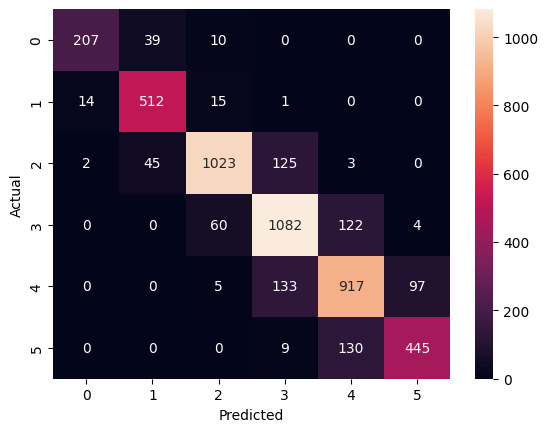

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## the model test on new data 

In [ ]:
new_data = pd.DataFrame([{
    "age": 16,
    "gender": "male",
    "school_type": "public",
    "parent_education": "high_school",
    "study_hours": 3.5,
    "attendance_percentage": 85,
    "internet_access": "yes",
    "travel_time": "15-30 min",
    "extra_activities": "yes",
    "study_method": "group"
}])
new_data = new_data.reindex(columns=X_train.columns, fill_value=0)
new_data = new_data[X_train.columns]

prediction = pipe.predict(new_data)
print(prediction)

['d']


In [ ]:

# import joblib

# joblib.dump(pipe, "model.pkl")
# !pip install flask


   ---------------------------------------- 0/2 [werkzeug]
   ---------------------------------------- 0/2 [werkzeug]
   -------------------- ------------------- 1/2 [flask]
   ---------------------------------------- 2/2 [flask]




[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# from flask import Flask, request, render_template
# import joblib
# import pandas as pd

# app = Flask(__name__)

# # load trained pipeline
# model = joblib.load("model.pkl")

# @app.route("/")
# def home():
#     return render_template("index.html")

# @app.route("/predict", methods=["POST"])
# def predict():

#     data = {
#         "student_id": 1,
#         "age": float(request.form["age"]),
#         "gender": request.form["gender"],
#         "school_type": request.form["school_type"],
#         "parent_education": request.form["parent_education"],
#         "study_hours": float(request.form["study_hours"]),
#         "attendance_percentage": float(request.form["attendance"]),
#         "internet_access": request.form["internet"],
#         "travel_time": request.form["travel_time"],
#         "extra_activities": request.form["extra"],
#         "study_method": request.form["study_method"],
#         "math_score": float(request.form["math"]),
#         "science_score": float(request.form["science"]),
#         "english_score": float(request.form["english"]),
#         "overall_score": float(request.form["overall"])
#     }

#     df = pd.DataFrame([data])

#     # ensure column order matches training
#     df = df[model.feature_names_in_]

#     prediction = model.predict(df)[0]

#     return render_template("index.html", prediction=prediction)
# if __name__ == "__main__":
#     app.run(debug=True, use_reloader=False)    

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [16/May/2026 11:18:05] "GET / HTTP/1.1" 500 -
Traceback (most recent call last):
  File "c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 1536, in __call__
    return self.wsgi_app(environ, start_response)
           ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 1514, in wsgi_app
    response = self.handle_exception(e)
  File "c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
  File "c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
  File "c:\Users\muham\AppData\Local\Programs\Python\Python313\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv

In [1]:
# @app.route("/")
# def home():
#     return "Flask is working!"